In [1]:
print("This is a test from AzureML")

This is a test from AzureML


In [3]:
import sys
!{sys.executable} -m pip install seaborn

## 1. Conexión a Azure ML y carga de datos

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("Australian_Rain", version="1")

df = pd.read_csv(data_asset.path)
df

Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [5]:
print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 145,460 filas × 23 columnas


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2. Exploración y análisis descriptivo

In [6]:
# Tipos de dato y valores nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
# Estadísticos descriptivos de las columnas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


In [8]:
# Porcentaje de valores nulos por columna
nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Porcentaje de nulos por columna:\n")
print(nulos.to_string())

Porcentaje de nulos por columna:

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
WindDir3pm        2.906641
Temp3pm           2.481094
RainTomorrow      2.245978
Rainfall          2.241853
RainToday         2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
Temp9am           1.214767
WindSpeed9am      1.214767
MinTemp           1.020899
MaxTemp           0.866905
Location          0.000000
Date              0.000000


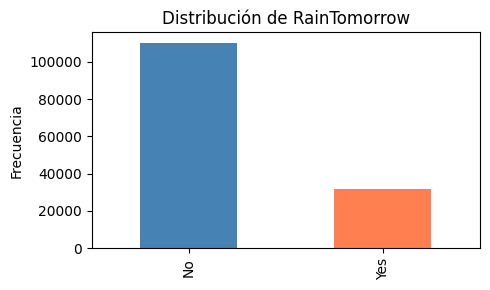

No     0.776
Yes    0.224
Name: RainTomorrow, dtype: float64


In [9]:
# Distribución de la variable objetivo 
fig, ax = plt.subplots(figsize=(5, 3))
df["RainTomorrow"].value_counts().plot.bar(color=["steelblue", "coral"], ax=ax)
ax.set_title("Distribución de RainTomorrow")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Proporción exacta
print(df["RainTomorrow"].value_counts(normalize=True).round(3))

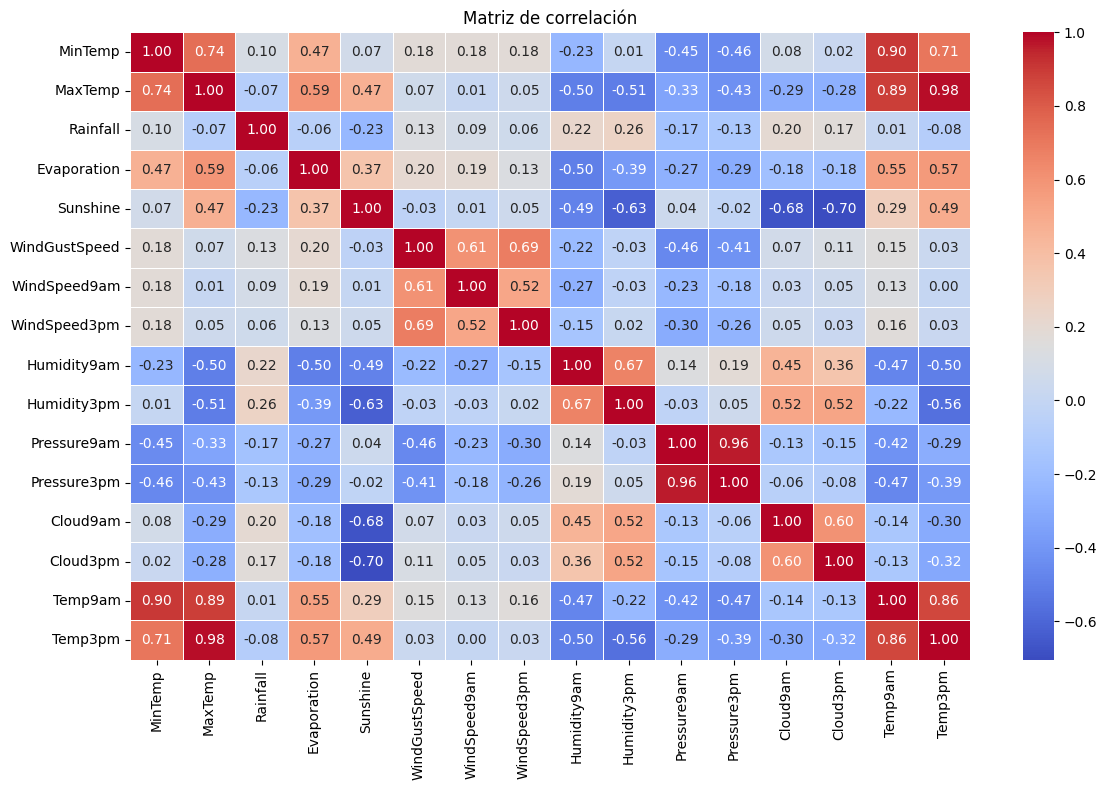

In [10]:
# Mapa de calor: correlación entre variables numéricas
numericas = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 3. Limpieza y preprocesamiento

In [11]:
# Copia de trabajo
data = df.copy()

# Eliminar filas sin variable objetivo
data.dropna(subset=["RainTomorrow"], inplace=True)

# Codificar la variable objetivo: Yes=1, No=0 
data["RainTomorrow"] = data["RainTomorrow"].map({"Yes": 1, "No": 0})

# Codificar RainToday de la misma forma
data["RainToday"] = data["RainToday"].map({"Yes": 1, "No": 0})

# Eliminar columnas que no aportan al modelo
# Date: componente temporal que no usaremos en un modelo sencillo
# Location: alta cardinalidad, lo descartamos por simplicidad
data.drop(columns=["Date", "Location"], inplace=True)

print(f"Shape después de limpieza inicial: {data.shape}")
data.head()

Shape después de limpieza inicial: (142193, 21)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0
1,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0
2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0
3,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,0
4,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0


In [12]:
# Separar columnas numéricas y categóricas ──
col_num = data.select_dtypes(include="number").columns.tolist()
col_cat = data.select_dtypes(include="object").columns.tolist()

print(f"Numéricas ({len(col_num)}): {col_num}")
print(f"Categóricas ({len(col_cat)}): {col_cat}")

Numéricas (18): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
Categóricas (3): ['WindGustDir', 'WindDir9am', 'WindDir3pm']


In [13]:
# Imputar nulos numéricos con la mediana
for col in col_num:
    if data[col].isnull().sum() > 0:
        mediana = data[col].median()
        data[col].fillna(mediana, inplace=True)

#  Imputar nulos categóricos con la moda 
for col in col_cat:
    if data[col].isnull().sum() > 0:
        moda = data[col].mode()[0]
        data[col].fillna(moda, inplace=True)

# Verificar que no queden nulos 
assert data.isnull().sum().sum() == 0, "Aún quedan nulos"
print("Sin valores nulos.")

Sin valores nulos.


In [14]:
#  One-Hot Encoding para las columnas categóricas restantes 
data = pd.get_dummies(data, columns=col_cat, drop_first=True, dtype=int)

print(f"Shape final tras encoding: {data.shape}")
data.head()

Shape final tras encoding: (142193, 63)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,...,0,0,0,0,0,0,0,0,1,0
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,...,0,0,0,0,0,0,0,0,0,1
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,...,0,0,0,0,0,0,0,0,0,1
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,...,0,0,0,0,0,0,0,0,0,0
4,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,...,0,1,0,0,0,0,0,0,0,0


## 4. Entrenamiento del modelo

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#  Separar features (X) y target (y)
X = data.drop(columns=["RainTomorrow"])
y = data["RainTomorrow"]

#  División 80/20 estratificada
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba:        {X_test.shape[0]:,} filas")

Entrenamiento: 113,754 filas
Prueba:        28,439 filas


In [16]:
# Escalado de features 
# Logistic Regression es sensible a la escala de las variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Entrenar Logistic Regression
# max_iter alto para asegurar convergencia con muchas features
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 5. Evaluación del modelo

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

# Predicciones sobre el conjunto de prueba 
y_pred  = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]  # probabilidad clase positiva

# Métricas principales 
metricas = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-Score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
}

for nombre, valor in metricas.items():
    print(f"{nombre:>10}: {valor:.4f}")

  Accuracy: 0.8449
 Precision: 0.7246
    Recall: 0.4969
  F1-Score: 0.5896
   ROC-AUC: 0.8678


In [18]:
# Reporte de clasificación completo
print(classification_report(y_test, y_pred, target_names=["No llueve", "Llueve"]))

              precision    recall  f1-score   support

   No llueve       0.87      0.95      0.90     22064
      Llueve       0.72      0.50      0.59      6375

    accuracy                           0.84     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.83      0.84      0.83     28439



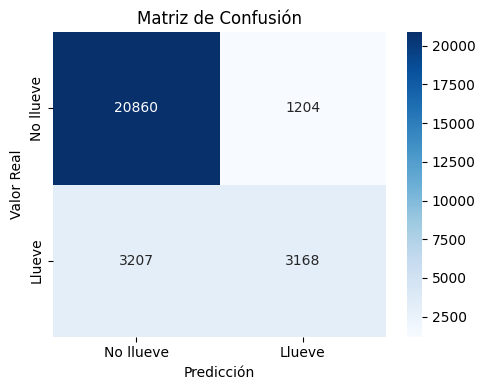

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No llueve", "Llueve"],
            yticklabels=["No llueve", "Llueve"], ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor Real")
ax.set_title("Matriz de Confusión")
plt.tight_layout()
plt.show()

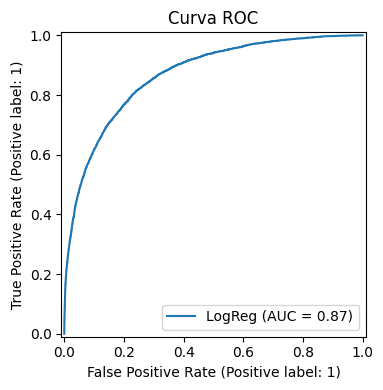

In [20]:
# Curva ROC
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="LogReg")
ax.set_title("Curva ROC")
plt.tight_layout()
plt.show()

## 6. Registro del modelo en Azure ML

In [21]:
import joblib
import os
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

# Guardar el modelo y el scaler localmente
model_dir = "model_artifacts"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(modelo,  os.path.join(model_dir, "modelo_lluvia.pkl"))
joblib.dump(scaler,  os.path.join(model_dir, "scaler.pkl"))

# Guardar nombres de features para reproducibilidad
joblib.dump(list(X.columns), os.path.join(model_dir, "feature_names.pkl"))

print(f"Artefactos guardados en ./{model_dir}/")

Artefactos guardados en ./model_artifacts/


In [22]:
# Registrar el modelo en Azure ML
modelo_azure = Model(
    path=model_dir,                       # carpeta con los .pkl
    name="rain-prediction-logreg",         # nombre en el registro
    description="Logistic Regression para predecir lluvia en Australia",
    type=AssetTypes.CUSTOM_MODEL,          # tipo genérico
)

modelo_registrado = ml_client.models.create_or_update(modelo_azure)

print(f"Modelo registrado: {modelo_registrado.name}")
print(f"Versión:           {modelo_registrado.version}")

Uploading model_artifacts (0.01 MBs): 100%|██████████| 5640/5640 [00:00<00:00, 174809.16it/s]




Modelo registrado: rain-prediction-logreg
Versión:           1
